# Dependencies

In [1]:
import pickle
import numpy as np
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler, MinMaxScaler, normalize as sk_normalize

import torch

import matplotlib.pyplot as plt

In [2]:
L = 4500 # original length
tp = 1
l = int(L/tp) # after patch
N = 20
D = 192
sample_frequency = 5

fmr1_fold_1 = {"train":[402, 404, 405, 406, 407, 408], "valid": [401, 403]}
fmr1_fold_2 = {"train":[401, 403, 405, 406, 407, 408], "valid": [402, 404]}
fmr1_fold_3 = {"train":[401, 402, 403, 404, 407, 408], "valid": [405, 406]}
fmr1_fold_4 = {"train":[401, 402, 404, 405, 406, 407], "valid": [403, 408]}

In [3]:
# Prediction Result
test_labels = [
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]

test_predictions = [
    1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
    1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
    0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
    1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
    0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0
]

correct_indices = [i for i, (y, p) in enumerate(zip(test_labels, test_predictions)) if y == p]
print(len(correct_indices))

83


# Mil Features Analysis

In [4]:
def normalize_frames(frames, cls_tokens, eps=1e-8):
    """L2-normalize both frames and class tokens along D."""
    frames_n = frames / (np.linalg.norm(frames, axis=-1, keepdims=True) + eps)
    cls_n = cls_tokens / (np.linalg.norm(cls_tokens, axis=-1, keepdims=True) + eps)
    return frames_n, cls_n

def compute_frame_importance(frames, cls_tokens, method="dot"):
    """
    frames, cls_tokens should already be normalized (see normalize_frames).
    method: "dot" (== cosine after normalization) | "softmax_dot"
    """
    cls = cls_tokens[:, None, :]  # (n, 1, D)
    dot = np.sum(frames * cls, axis=-1)  # (n, L)
    if method == "dot":
        return dot
    if method == "softmax_dot":
        D = frames.shape[-1]
        scaled = dot / np.sqrt(D)
        scaled -= scaled.max(axis=-1, keepdims=True)
        exp = np.exp(scaled)
        return exp / exp.sum(axis=-1, keepdims=True)


def plot_importance_heatmap(importance, title="Frame Importance", xlabel="Frame index", ylabel="Sequence", normalize="row"):
    """
    normalize: None | "row" (per-sequence min-max, best for spotting relative peaks)| "global" (min-max across whole array)
    clip_percentile: clip top/bottom p% before scaling color, to kill outlier dominance
    """
    n, L = importance.shape
    imp = importance.copy()

    if normalize == "row":
        row_min = imp.min(axis=1, keepdims=True)
        row_max = imp.max(axis=1, keepdims=True)
        imp = (imp - row_min) / (row_max - row_min + 1e-8)
    elif normalize == "global":
        imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)

    figsize = (min(0.15 * L, 15), min(0.25 * n, 9))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(imp, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Importance (normalized)")
    plt.tight_layout()
    return imp,fig, ax

## load model + parameters

In [2]:
import sys
sys.path.append("/home/rguo_hpc/myfolder/mocap")
from mil.models.timemil import TimeMIL
import torch

milnet = TimeMIL(in_features=192, mDim=192, n_classes=2, dropout=0.25,max_seq_len=4500,
                 if_extract_feature=True, if_interval=False, instance_len=30)
checkpoint = torch.load("./t1/mil/best_model.pth", weights_only=False, map_location="cpu")
milnet.load_state_dict(checkpoint)

<All keys matched successfully>

In [15]:
attn_to_qkv1 = milnet.layer1.attn.to_qkv.weight.detach().cpu().numpy() # (576, 192)
q1,k1 = attn_to_qkv1[:192], attn_to_qkv1[192:384]

attn_to_qkv2 = milnet.layer2.attn.to_qkv.weight.detach().cpu().numpy() # (576, 192)
q2,k2 = attn_to_qkv2[:192], attn_to_qkv2[192:384]

In [7]:
for name, param in milnet.named_parameters():
    if "attn" in name:
        print(f"{name}: {param.shape}")

layer1.attn.to_qkv.weight: torch.Size([576, 192])
layer1.attn.to_out.0.weight: torch.Size([192, 192])
layer1.attn.to_out.0.bias: torch.Size([192])
layer1.attn.res_conv.weight: torch.Size([8, 1, 33, 1])
layer2.attn.to_qkv.weight: torch.Size([576, 192])
layer2.attn.to_out.0.weight: torch.Size([192, 192])
layer2.attn.to_out.0.bias: torch.Size([192])
layer2.attn.res_conv.weight: torch.Size([8, 1, 33, 1])


In [ ]:
# Representations learned after mil
raw_feats = np.load('/home/rguo_hpc/myfolder/mocap/outputs/representations/fmr1/t1/mil/representations.npy')
#raw_feats = np.load('/home/rguo_hpc/myfolder/mocap/outputs/representations/fmr1/t3/representations/timemil_cls/representations.npy')

# Take validation set only
frames = raw_feats[360:, 50:4450][correct_indices]#[correct_indices, ::sample_frequency]
cls = raw_feats[360:, 0][correct_indices]
print(frames.shape)
print(cls.shape)
del raw_feats

(83, 4400, 192)
(83, 192)


In [22]:
# Normalize
frames_n, cls_n = normalize_frames(frames, cls)

In [ ]:
def softmax(x, axis=-1):
    exp_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

In [ ]:
scale = 192 ** -0.5

A1 = cls_n @ q1
B1 = frames_n @ k1
out1 = np.einsum('blc,bc->bl', B1, A1)
scores1 = out1 * scale 
attn1 = softmax(out1, axis=1)

In [ ]:
A2 = cls_n @ q2
B2 = frames_n @ k2
out2 = np.einsum('blc,bc->bl', B2, A2)
scores2 = out2 * scale 
attn2 = softmax(out2, axis=1)

In [43]:
#importance = compute_frame_importance(frames, cls, method="softmax_dot")
#importance = compute_frame_importance(frames_n, cls_n, method="softmax_dot")
importance = (attn1 + attn2)/2

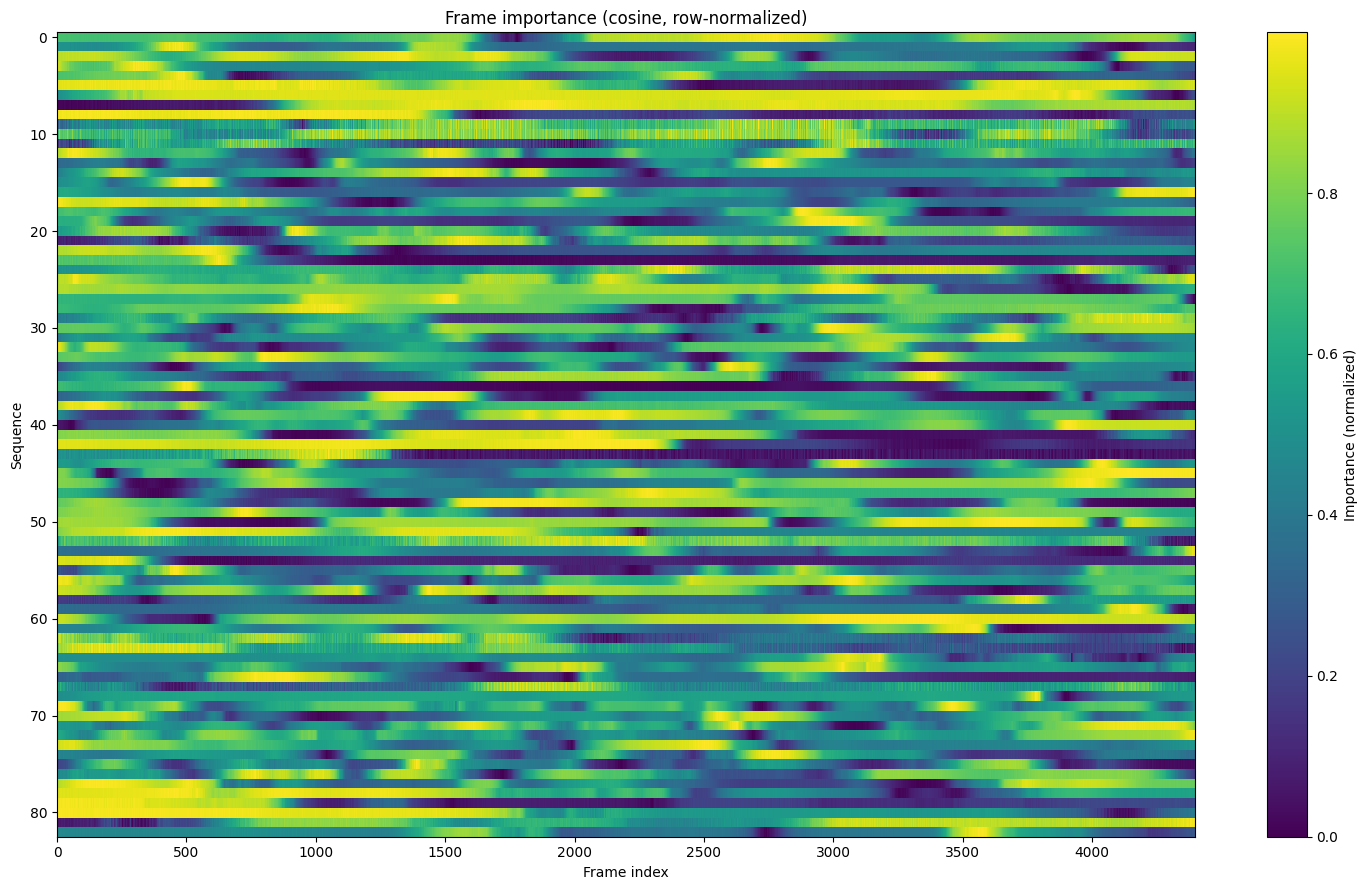

In [45]:
imp, fig, ax = plot_importance_heatmap(importance[:3500], title="Frame importance (cosine, row-normalized)", normalize="row")
plt.show()

# Check labels
## load labels

In [46]:
# load original data 
with open("/home/rguo_hpc/myfolder/data/sdannce/data_fmr1.pkl", 'rb') as file:
    result = pickle.load(file)

for mouse in result.keys():     # result.keys(): [408, 407, 404, 403, 402, 406, 405, 401]
    num_seq = len(result[mouse]["ratgen"])
    ratgen  = int(result[mouse]["ratgen"][0])
    result[mouse]["ratgen"] = [ratgen for i in range(num_seq * N,)]
    ratid = result[mouse]["ratid"][0]
    result[mouse]["ratid"] = [ratid for i in range(num_seq * N,)]
    
    # llac    
    llac = np.array(result[mouse]["llac"])
    llac = np.squeeze(llac, axis=2)
    llac = llac.reshape(-1, L,)
    if tp > 1:
        grouped_llac = llac.reshape(-1, l, tp) # choose the mode label of each patch 
        result[mouse]["llac"] = mode(grouped_llac, axis=2, keepdims=False).mode.astype(np.uint8)
    else:
        result[mouse]["llac"] = llac
    
    # hlac
    hlac = np.array(result[mouse]["hlac"]) # (3, 90000, 1)
    hlac = np.squeeze(hlac, axis=2)
    hlac = hlac.reshape(-1, L,)
    if tp > 1:
        grouped_hlac = hlac.reshape(-1, l, 3)
        result[mouse]["hlac"] = mode(grouped_hlac, axis=2, keepdims=False).mode.astype(np.uint8)
    else:
        result[mouse]["hlac"] = hlac
    
    del result[mouse]["m1"]

In [47]:
hlac_val, llac_val = [], []
for mouse_id in fmr1_fold_1["valid"]:
    hlac_val.append(result[mouse_id]["hlac"])
    llac_val.append(result[mouse_id]["llac"]) 
    
hlac_val = np.concatenate(hlac_val)[correct_indices, 50:4450]#[:,::sample_frequency]
llac_val = np.concatenate(llac_val)[correct_indices, 50:4450]#[:,::sample_frequency]
print(hlac_val.shape)

(83, 4400)


In [51]:
selected_labels = hlac_val[imp > 0.98]
unique, counts = np.unique(selected_labels, return_counts=True)
distribution = dict(zip(unique, counts))
print(distribution)

attention_mask = np.where(imp > 0.95, 1, 0)
hlac_mask = attention_mask * hlac_val

{1: 1111, 2: 2444, 3: 101, 4: 510, 5: 58, 6: 771, 7: 1431, 8: 503}


In [52]:
import matplotlib.colors as mcolors

def plot_label_heatmap(labels, title="Label Map", xlabel="Frame index", ylabel="Sequence", cmap_name="tab10"):
    """
    Plot a discrete-valued array (integers 1..8) with categorical coloring.

    labels: (n, L) array of ints in [1, 8]
    cmap_name: any qualitative colormap with >=8 colors (e.g. "tab10", "Set1")
    """
    n, L = labels.shape
    vmin, vmax = 0, 8

    # Build a discrete colormap with exactly 8 distinct colors
    base_cmap = plt.get_cmap(cmap_name, vmax - vmin + 1)
    bounds = np.arange(vmin - 0.5, vmax + 1.5, 1)  # bin edges centered on integers
    norm = mcolors.BoundaryNorm(bounds, base_cmap.N)

    figsize = (min(0.15 * L, 15), min(0.25 * n, 9))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(labels, aspect="auto", cmap=base_cmap, norm=norm, interpolation="nearest")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(vmin, vmax + 1), label="Label")
    cbar.ax.set_yticklabels([str(i) for i in range(vmin, vmax + 1)])

    plt.tight_layout()
    return fig, ax

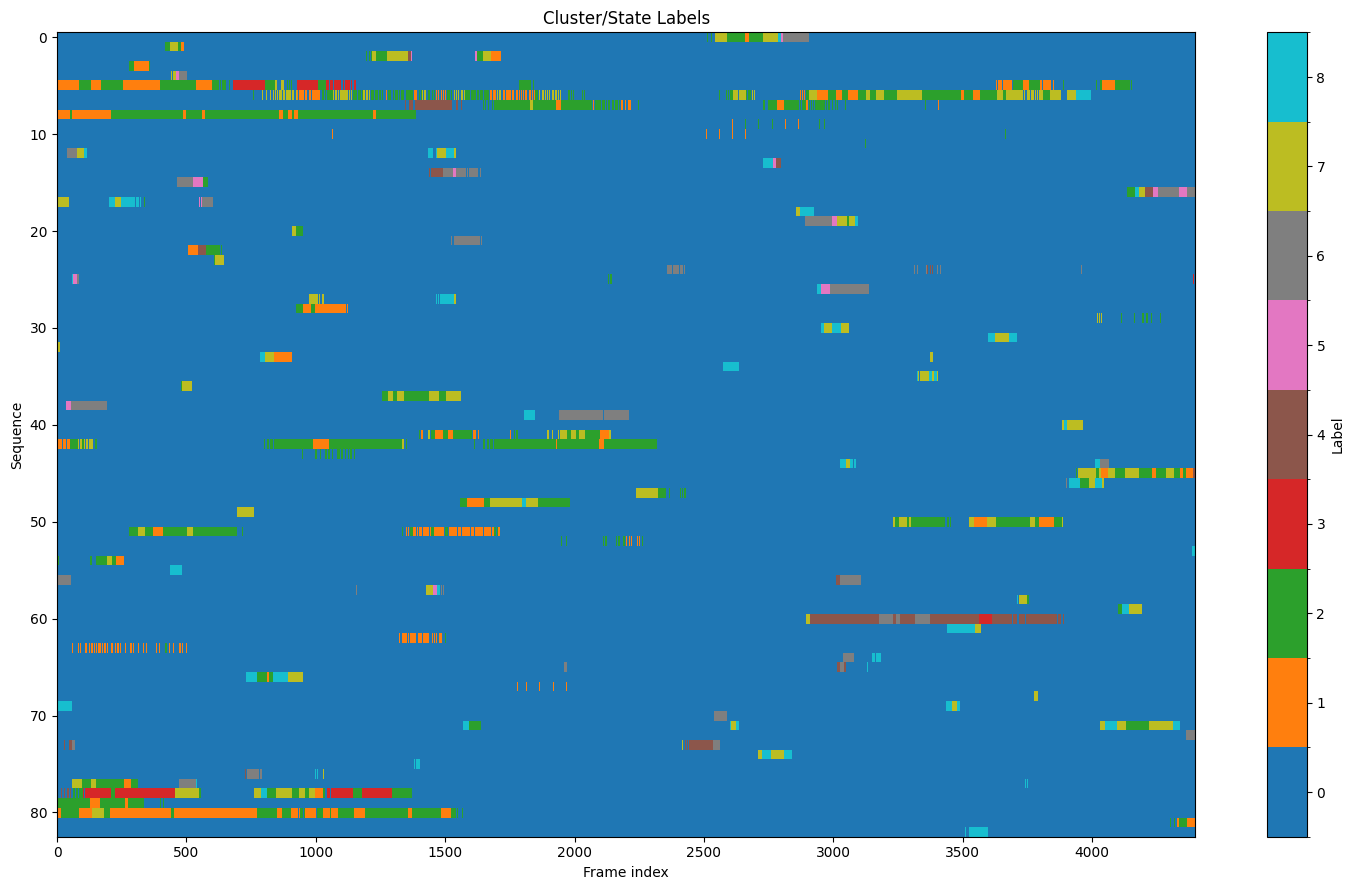

In [53]:
fig, ax = plot_label_heatmap(hlac_mask, title="Cluster/State Labels")